# Classical LBM Solver + Dataset Generator
## 2D Convecting Taylor-Green Vortex — Airbus Quantum+AI Challenge 2026

This notebook implements a complete, validated D2Q9 Lattice Boltzmann solver and generates training datasets for the downstream quantum (VQC) and ML (FNO) components.

### What this notebook produces
| Output | Location | Used by |
|--------|----------|---------|
| HDF5 datasets | `dataset/lbm_Re{Re}_N{N}.h5` | VQC training, FNO training |
| Validation plots | `figures/` | Submission report |
| Summary table | notebook output | Quick sanity check |

### Dataset structure (per file)
```
/metadata         → Re, N, nu, dt, dx, scale, L
/times            → snapshot times [T]
/u, /v            → LBM velocity fields [T, N, N]  ← FNO input
/f                → distribution functions [T, 9, N, N]  ← VQC input
/u_exact, /v_exact→ analytical solution [T, N, N]  ← FNO target
/f_eq_exact       → equilibrium f_eq [T, 9, N, N]  ← VQC collision target
/l2_errors        → L2 error per snapshot [T]
/ke_sim, /ke_exact→ kinetic energy [T]
```

### Key implementation note — lattice units
LBM operates in dimensionless lattice units. Physical velocities must be scaled:
```
u_physical = u_lattice × (dx/dt)
```
Collision happens in lattice units; all outputs are stored in physical units.

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import os
import time
from tqdm import tqdm

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
os.makedirs('dataset', exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('Ready.')

Ready.


## 2. Physical Parameters (PDF Section 6)

In [2]:
# ── Physical constants ──────────────────────────────────────────────────────
L    = 2 * np.pi   # domain size [m]
V0   = 1.0         # vortex intensity [m/s]
Uc   = 1.0         # convection velocity x [m/s]
Vc   = 0.0         # convection velocity y [m/s]
rho0 = 1.0         # fluid density [kg/m^3]
p0   = 0.0         # background pressure [Pa]

# ── Simulation configuration ─────────────────────────────────────────────────
# Grid size chosen so that LBM relaxation time 0.5 < tau < 2.0 (stability)
# Lattice velocity U_lat set so Mach = U_lat * sqrt(3) << 1 (incompressible)
RE_CFG = {
    10:   {'N': 32,  'U_lat': 0.05},   # tau=0.74, Mach=0.087
    100:  {'N': 64,  'U_lat': 0.05},   # tau=0.55, Mach=0.087
    400:  {'N': 128, 'U_lat': 0.03},   # tau=0.51, Mach=0.052
    1000: {'N': 256, 'U_lat': 0.02},   # tau=0.51, Mach=0.035
}

T_END   = 1.0    # simulation end time [s]
N_SAVE  = 20     # snapshots saved per simulation

for Re, cfg in RE_CFG.items():
    N, U_lat = cfg['N'], cfg['U_lat']
    U_max = abs(Uc) + V0
    dx  = L / N
    dt  = U_lat * dx / U_max
    nu  = V0 * L / Re
    nu_l = nu * dt / dx**2
    tau = 0.5 + nu_l / (1/3)
    mach = U_lat * np.sqrt(3)
    print(f'Re={Re:5d}  N={N:4d}  tau={tau:.4f}  Mach={mach:.3f}  steps={int(T_END/dt):6d}')

Re=   10  N=  32  tau=0.7400  Mach=0.087  steps=   203
Re=  100  N=  64  tau=0.5480  Mach=0.087  steps=   407
Re=  400  N= 128  tau=0.5144  Mach=0.052  steps=  1358
Re= 1000  N= 256  tau=0.5077  Mach=0.035  steps=  4074


## 3. D2Q9 Lattice Constants

In [3]:
# D2Q9 discrete velocity directions:
#  6  2  5
#  3  0  1
#  7  4  8
EX  = np.array([ 0,  1,  0, -1,  0,  1, -1, -1,  1], dtype=np.float64)
EY  = np.array([ 0,  0,  1,  0, -1,  1,  1, -1, -1], dtype=np.float64)
W   = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36], dtype=np.float64)
CS2 = 1.0 / 3.0   # speed of sound squared (lattice units)
print('D2Q9 weights sum:', W.sum())   # must be 1.0
print('Directions:', list(zip(EX.astype(int), EY.astype(int))))

D2Q9 weights sum: 1.0
Directions: [(np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(-1), np.int64(0)), (np.int64(0), np.int64(-1)), (np.int64(1), np.int64(1)), (np.int64(-1), np.int64(1)), (np.int64(-1), np.int64(-1)), (np.int64(1), np.int64(-1))]


## 4. Core Functions
### 4.1 Analytical solution (PDF Section 5.3)

In [4]:
def analytical_solution(x, y, t, nu):
    """
    Exact closed-form solution for the 2D Convecting Taylor-Green Vortex.

    u(x,y,t) = Uc + V0*sin((x-Uc*t)/L)*cos((y-Vc*t)/L)*exp(-2*nu*t/L^2)
    v(x,y,t) = Vc - V0*cos((x-Uc*t)/L)*sin((y-Vc*t)/L)*exp(-2*nu*t/L^2)
    """
    decay = np.exp(-2.0 * nu * t / L**2)
    xi    = (x - Uc * t) / L
    eta   = (y - Vc * t) / L
    u = Uc + V0 * np.sin(xi) * np.cos(eta) * decay
    v = Vc - V0 * np.cos(xi) * np.sin(eta) * decay
    p = p0 + (rho0 * V0**2 / 4) * (np.cos(2*xi) + np.cos(2*eta)) * decay**2
    return u, v, p

# Quick test
N_test = 32
dx_t   = L / N_test
x1d    = np.linspace(0, L - dx_t, N_test)
x_t, y_t = np.meshgrid(x1d, x1d, indexing='ij')
u0, v0, _ = analytical_solution(x_t, y_t, 0.0, V0*L/10)
ke0 = 0.5 * np.mean(u0**2 + v0**2)
print(f'u at t=0: [{u0.min():.4f}, {u0.max():.4f}]')
print(f'v at t=0: [{v0.min():.4f}, {v0.max():.4f}]')
print(f'KE at t=0: {ke0:.5f}  (expected ~1.07)')

u at t=0: [1.0000, 1.8242]
v at t=0: [-0.8242, 0.0000]
KE at t=0: 1.07211  (expected ~1.07)


### 4.2 LBM kernels

In [5]:
def equilibrium(rho, ul, vl):
    """
    Maxwell-Boltzmann equilibrium distribution in LATTICE units.

    f_i^eq = w_i * rho * [1 + (e_i.u)/cs2 + (e_i.u)^2/(2cs2^2) - u^2/(2cs2)]

    Parameters: ul, vl are LATTICE velocities (physical / scale)
    """
    feq = np.zeros((9,) + ul.shape)
    usq = ul**2 + vl**2
    for i in range(9):
        eu = EX[i]*ul + EY[i]*vl
        feq[i] = W[i] * rho * (1.0 + eu/CS2 + eu**2/(2*CS2**2) - usq/(2*CS2))
    return feq


def stream(f):
    """
    Streaming step — shift each f_i in its velocity direction.
    Periodic BCs via np.roll.
    This step is EXACTLY unitary (pure cyclic permutation) — directly
    maps to a quantum shift circuit without approximation.
    """
    for i in range(9):
        f[i] = np.roll(np.roll(f[i], int(EX[i]), axis=0), int(EY[i]), axis=1)
    return f


def macroscopic(f):
    """Compute density and LATTICE velocities from f."""
    rho = f.sum(axis=0)
    ul  = (f * EX[:,None,None]).sum(axis=0) / rho
    vl  = (f * EY[:,None,None]).sum(axis=0) / rho
    return rho, ul, vl


def l2_error(u_sim, v_sim, u_ex, v_ex):
    """Relative L2 error norm — PDF section 4.1 metric (i)."""
    num   = np.sqrt(np.mean((u_sim - u_ex)**2 + (v_sim - v_ex)**2))
    denom = np.sqrt(np.mean(u_ex**2 + v_ex**2)) + 1e-12
    return num / denom

print('LBM kernels defined.')

LBM kernels defined.


## 5. Main Simulation Loop

In [6]:
def run_lbm(Re, verbose=True):
    """
    Run D2Q9 LBM for the 2D Convecting Taylor-Green Vortex.

    Returns a dict with:
        times, u_fields, v_fields, f_fields   — snapshots
        u_exact_fields, v_exact_fields         — analytical targets
        f_eq_exact_fields                      — VQC collision targets
        l2_errors, ke_sim, ke_exact            — metrics
        metadata dict
    """
    cfg   = RE_CFG[Re]
    N     = cfg['N']
    U_lat = cfg['U_lat']
    U_max = abs(Uc) + V0

    dx    = L / N
    dt    = U_lat * dx / U_max
    nu    = V0 * L / Re
    nu_l  = nu * dt / dx**2
    tau   = 0.5 + nu_l / CS2
    omega = 1.0 / tau
    scale = dx / dt            # u_physical = u_lattice * scale

    n_steps   = int(T_END / dt)
    save_every = max(1, n_steps // N_SAVE)

    if verbose:
        print(f'\n{"="*56}')
        print(f'  Re={Re}, N={N}x{N}')
        print(f'  tau={tau:.4f}  omega={omega:.4f}  scale={scale:.1f}')
        print(f'  dt={dt:.5f}  nu={nu:.5f}  nu_lat={nu_l:.5f}')
        print(f'  steps={n_steps}  Mach={U_lat*np.sqrt(3):.3f}')
        print(f'{"="*56}')

    # grid
    x1d  = np.linspace(0, L - dx, N)
    x, y = np.meshgrid(x1d, x1d, indexing='ij')

    # initialize from analytical IC converted to lattice units
    u0p, v0p, _ = analytical_solution(x, y, 0.0, nu)
    f = equilibrium(np.ones((N, N)) * rho0, u0p/scale, v0p/scale)
    t_now = 0.0

    times, u_list, v_list, f_list = [], [], [], []
    ue_list, ve_list, feq_list    = [], [], []
    l2s, ke_s, ke_e               = [], [], []

    t_wall = time.perf_counter()
    for s in tqdm(range(n_steps), desc=f'Re={Re}', disable=not verbose):

        if s % save_every == 0:
            rho_, ul_, vl_ = macroscopic(f)
            up_ = ul_ * scale          # back to physical units
            vp_ = vl_ * scale
            ue, ve, _      = analytical_solution(x, y, t_now, nu)
            ue_feq         = equilibrium(np.ones((N,N))*rho0, ue/scale, ve/scale)

            times.append(t_now)
            u_list.append(up_.copy());  v_list.append(vp_.copy())
            f_list.append(f.copy())
            ue_list.append(ue.copy());  ve_list.append(ve.copy())
            feq_list.append(ue_feq.copy())
            l2s.append(l2_error(up_, vp_, ue, ve))
            ke_s.append(0.5 * np.mean(up_**2 + vp_**2))
            ke_e.append(0.5 * np.mean(ue**2 + ve**2))

        # BGK collision (in lattice units)
        # THIS is the nonlinear step VQC must learn to replicate
        rho_, ul_, vl_ = macroscopic(f)
        feq_bgk = equilibrium(rho_, ul_, vl_)
        f += omega * (feq_bgk - f)

        # streaming (exact unitary permutation)
        f = stream(f)
        t_now += dt

    runtime = time.perf_counter() - t_wall

    if verbose:
        print(f'  Finished in {runtime:.1f}s')
        print(f'  L2_final = {l2s[-1]:.4e}')
        print(f'  KE_sim   = {ke_s[-1]:.5f}  |  KE_exact = {ke_e[-1]:.5f}')

    return {
        'Re': Re, 'N': N, 'nu': nu, 'dt': dt, 'dx': dx,
        'tau': tau, 'scale': scale, 'runtime': runtime,
        'x': x, 'y': y,
        'times':          np.array(times),
        'u_fields':       np.stack(u_list),
        'v_fields':       np.stack(v_list),
        'f_fields':       np.stack(f_list),
        'u_exact_fields': np.stack(ue_list),
        'v_exact_fields': np.stack(ve_list),
        'f_eq_exact':     np.stack(feq_list),
        'l2_errors':      np.array(l2s),
        'ke_sim':         np.array(ke_s),
        'ke_exact':       np.array(ke_e),
    }

print('run_lbm() defined.')

run_lbm() defined.


## 6. Run Simulations

In [7]:
# Run all Reynolds numbers
# Re=10,100 are fast (< 1s). Re=400 ~3s. Re=1000 ~40s.
all_results = {}
for Re in [10, 100, 400, 1000]:
    all_results[Re] = run_lbm(Re, verbose=True)

print('\nAll simulations complete.')


  Re=10, N=32x32
  tau=0.7400  omega=1.3514  scale=40.0
  dt=0.00491  nu=0.62832  nu_lat=0.08000
  steps=203  Mach=0.087


Re=10:   0%|          | 0/203 [00:00<?, ?it/s]

Re=10:  65%|██████▍   | 131/203 [00:00<00:00, 1291.79it/s]

Re=10: 100%|██████████| 203/203 [00:00<00:00, 1271.56it/s]

  Finished in 0.2s
  L2_final = 2.9041e-01
  KE_sim   = 1.02811  |  KE_exact = 0.91438


...

Re=1000: 100%|█████████▉| 4062/4074 [00:46<00:00, 71.06it/s]

Re=1000: 100%|█████████▉| 4072/4074 [00:47<00:00, 77.03it/s]

Re=1000: 100%|██████████| 4074/4074 [00:47<00:00, 86.53it/s]

  Finished in 47.1s
  L2_final = 2.4668e-01
  KE_sim   = 1.05196  |  KE_exact = 0.94386



All simulations complete.


## 7. Validation Plots

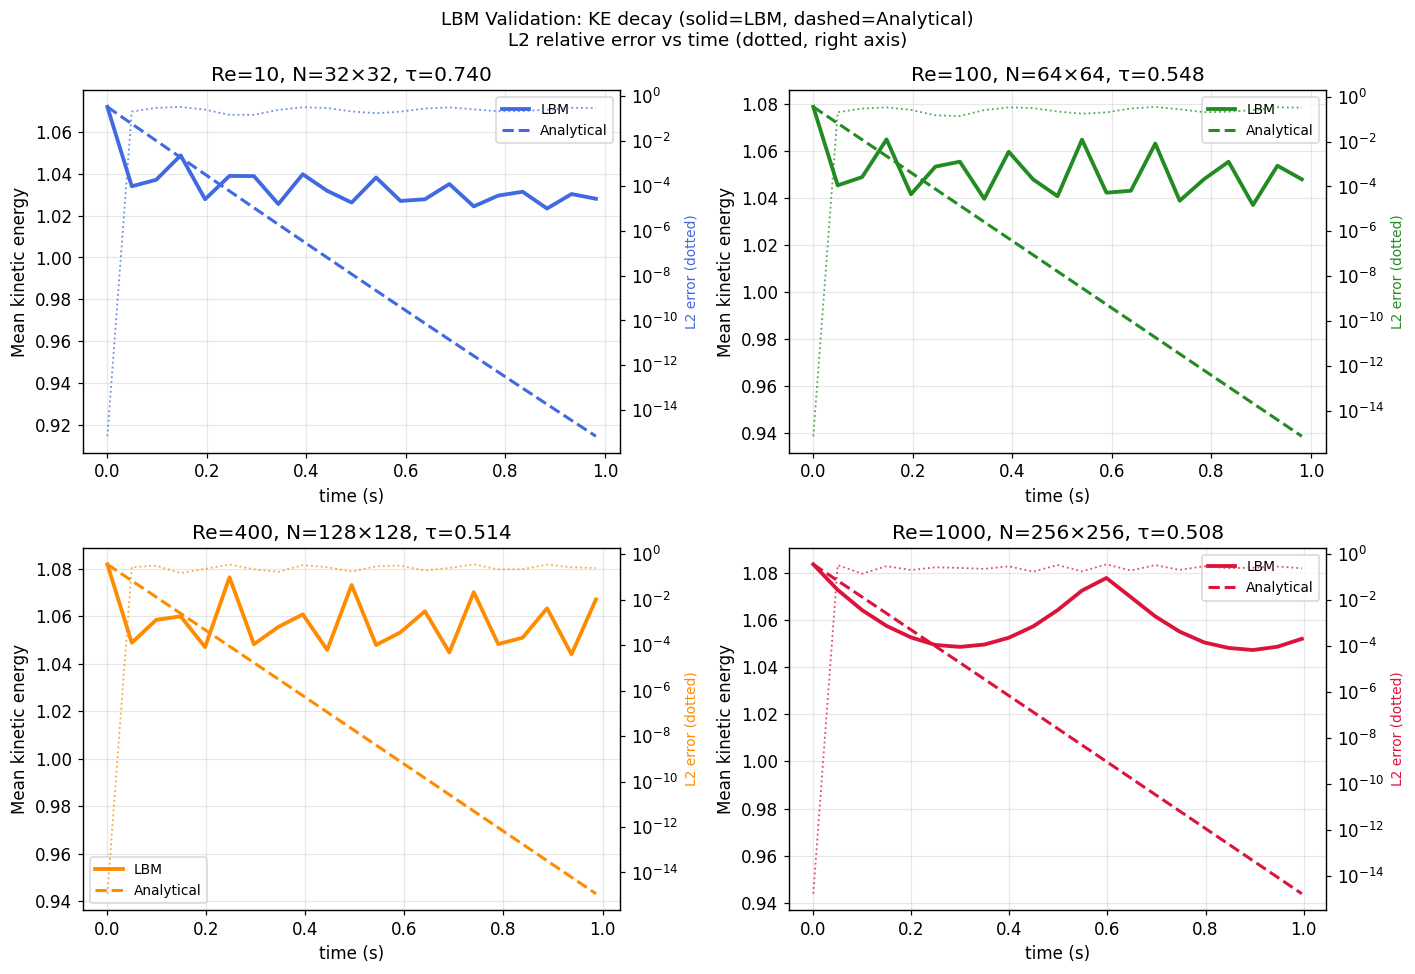

Saved: figures/validation_all.png


In [8]:
def plot_validation(all_results):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    colors = ['royalblue', 'forestgreen', 'darkorange', 'crimson']

    for ax, (Re, res), c in zip(axes.flat, sorted(all_results.items()), colors):
        # KE decay
        ax.plot(res['times'], res['ke_sim'],   color=c, lw=2.5, label='LBM')
        ax.plot(res['times'], res['ke_exact'], color=c, lw=2,   ls='--', label='Analytical')
        ax.set_xlabel('time (s)'); ax.set_ylabel('Mean kinetic energy')
        ax.set_title(f'Re={Re}, N={res["N"]}×{res["N"]}, τ={res["tau"]:.3f}')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        # L2 error on right axis
        ax2 = ax.twinx()
        ax2.semilogy(res['times'], res['l2_errors'],
                     color=c, lw=1.2, ls=':', alpha=0.75, label='L2 error')
        ax2.set_ylabel('L2 error (dotted)', color=c, fontsize=9)

    plt.suptitle('LBM Validation: KE decay (solid=LBM, dashed=Analytical)\n'
                 'L2 relative error vs time (dotted, right axis)', fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/validation_all.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: figures/validation_all.png')

plot_validation(all_results)

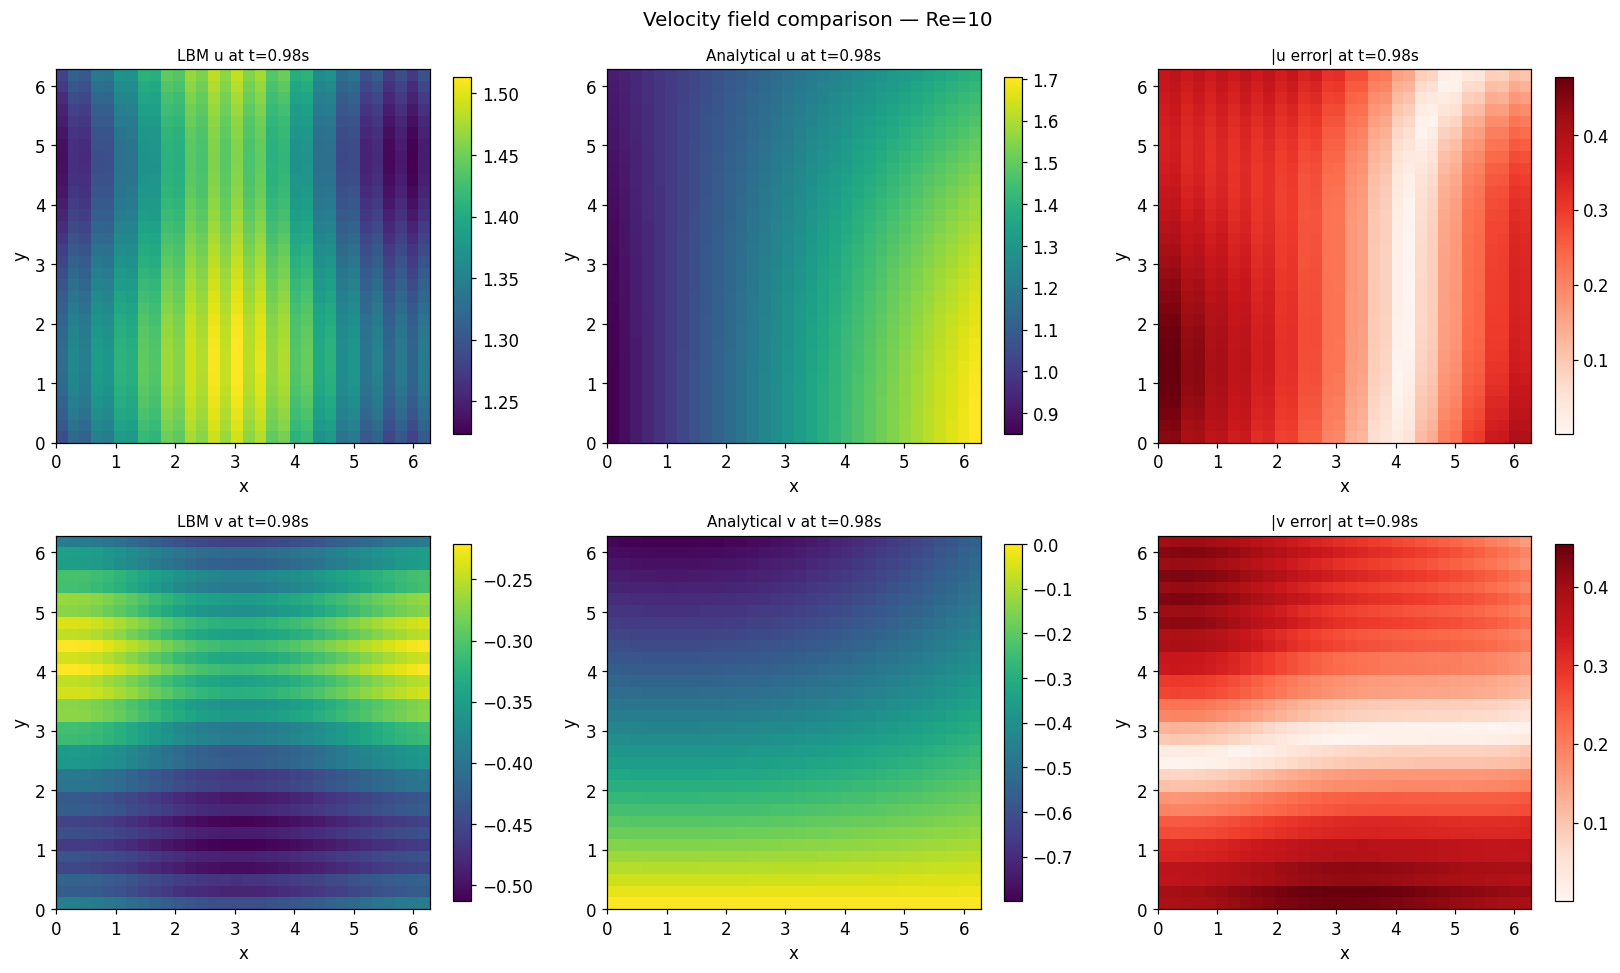

Saved: figures/velocity_field_Re10.png


In [9]:
def plot_velocity_field(res):
    Re = res['Re']; t_fin = res['times'][-1]
    u_sim = res['u_fields'][-1]; v_sim = res['v_fields'][-1]
    u_ex  = res['u_exact_fields'][-1]; v_ex = res['v_exact_fields'][-1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fields = [(u_sim, 'LBM u'), (u_ex, 'Analytical u'), (np.abs(u_sim-u_ex), '|u error|'),
              (v_sim, 'LBM v'), (v_ex, 'Analytical v'), (np.abs(v_sim-v_ex), '|v error|')]

    for ax, (field, title) in zip(axes.flat, fields):
        cmap = 'Reds' if 'error' in title else 'viridis'
        im = ax.imshow(field.T, origin='lower', extent=[0, L, 0, L], cmap=cmap)
        ax.set_title(f'{title} at t={t_fin:.2f}s', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        plt.colorbar(im, ax=ax, shrink=0.85)

    plt.suptitle(f'Velocity field comparison — Re={Re}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'figures/velocity_field_Re{Re}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/velocity_field_Re{Re}.png')

plot_velocity_field(all_results[10])

## 8. Scaling Analysis

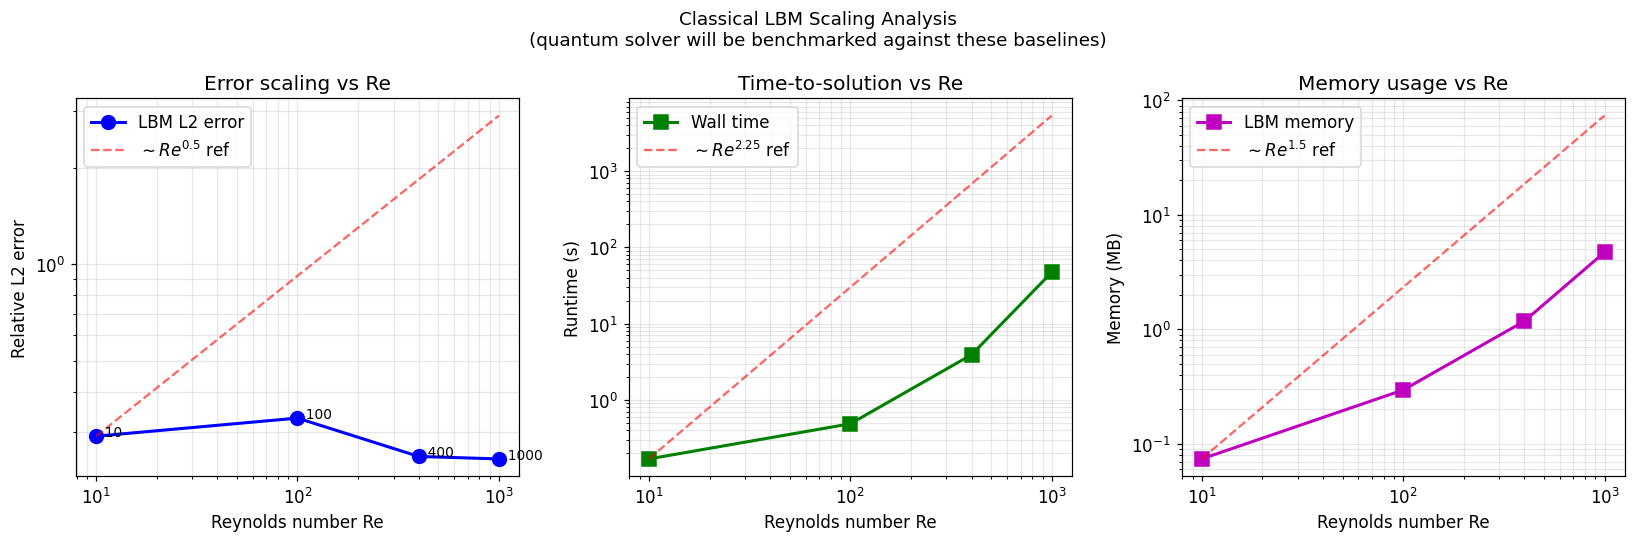

Saved: figures/scaling_analysis.png


In [10]:
def plot_scaling(all_results):
    re_vals  = sorted(all_results.keys())
    l2_f     = [all_results[r]['l2_errors'][-1] for r in re_vals]
    rts      = [all_results[r]['runtime']         for r in re_vals]
    ns       = [all_results[r]['N']               for r in re_vals]
    mem_mb   = [9 * n**2 * 8 / 1e6               for n in ns]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    re_arr = np.array(re_vals, dtype=float)

    ax = axes[0]
    ax.loglog(re_vals, l2_f, 'bo-', ms=9, lw=2, label='LBM L2 error')
    ax.loglog(re_arr, l2_f[0]*(re_arr/re_arr[0])**0.5,
              'r--', lw=1.5, alpha=0.6, label=r'$\sim Re^{0.5}$ ref')
    ax.set_xlabel('Reynolds number Re'); ax.set_ylabel('Relative L2 error')
    ax.set_title('Error scaling vs Re')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)
    for r, l in zip(re_vals, l2_f):
        ax.annotate(f'  {r}', (r, l), fontsize=9)

    ax = axes[1]
    ax.loglog(re_vals, rts, 'gs-', ms=9, lw=2, label='Wall time')
    ax.loglog(re_arr, rts[0]*(re_arr/re_arr[0])**2.25,
              'r--', lw=1.5, alpha=0.6, label=r'$\sim Re^{2.25}$ ref')
    ax.set_xlabel('Reynolds number Re'); ax.set_ylabel('Runtime (s)')
    ax.set_title('Time-to-solution vs Re')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)

    ax = axes[2]
    ax.loglog(re_vals, mem_mb, 'ms-', ms=9, lw=2, label='LBM memory')
    ax.loglog(re_arr, mem_mb[0]*(re_arr/re_arr[0])**1.5,
              'r--', lw=1.5, alpha=0.6, label=r'$\sim Re^{1.5}$ ref')
    ax.set_xlabel('Reynolds number Re'); ax.set_ylabel('Memory (MB)')
    ax.set_title('Memory usage vs Re')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)

    plt.suptitle('Classical LBM Scaling Analysis\n'
                 '(quantum solver will be benchmarked against these baselines)',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/scaling_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: figures/scaling_analysis.png')

plot_scaling(all_results)

## 9. Save Datasets

In [11]:
def save_hdf5(res):
    Re, N = res['Re'], res['N']
    fpath = f'dataset/lbm_Re{Re}_N{N}.h5'

    with h5py.File(fpath, 'w') as hf:
        # metadata
        m = hf.create_group('metadata')
        for k, v in [('Re', Re), ('N', N), ('nu', res['nu']),
                     ('dt', res['dt']), ('dx', res['dx']),
                     ('tau', res['tau']), ('scale', res['scale']),
                     ('L', L), ('V0', V0), ('Uc', Uc), ('Vc', Vc),
                     ('T_end', T_END)]:
            m.attrs[k] = v

        # time axis
        hf.create_dataset('times',          data=res['times'],          compression='gzip')

        # LBM output (physical units)
        hf.create_dataset('u',              data=res['u_fields'],       compression='gzip')
        hf.create_dataset('v',              data=res['v_fields'],       compression='gzip')

        # Distribution functions (lattice units) — VQC input
        hf.create_dataset('f',              data=res['f_fields'],       compression='gzip')

        # Analytical targets (physical units) — FNO target
        hf.create_dataset('u_exact',        data=res['u_exact_fields'], compression='gzip')
        hf.create_dataset('v_exact',        data=res['v_exact_fields'], compression='gzip')

        # Equilibrium targets (lattice units) — VQC collision target
        hf.create_dataset('f_eq_exact',     data=res['f_eq_exact'],     compression='gzip')

        # Metrics
        hf.create_dataset('l2_errors',      data=res['l2_errors'],      compression='gzip')
        hf.create_dataset('ke_sim',         data=res['ke_sim'],         compression='gzip')
        hf.create_dataset('ke_exact',       data=res['ke_exact'],       compression='gzip')

    size = os.path.getsize(fpath) / 1e6
    T    = len(res['times'])
    print(f'  {fpath}  ({size:.1f} MB)')
    print(f'    f shape:         {res["f_fields"].shape}   ← VQC input')
    print(f'    f_eq_exact:      {res["f_eq_exact"].shape}   ← VQC collision target')
    print(f'    u_exact:         {res["u_exact_fields"].shape}   ← FNO target')


print('Saving all datasets...')
for Re, res in all_results.items():
    save_hdf5(res)
print('Done.')

Saving all datasets...
  dataset/lbm_Re10_N32.h5  (3.4 MB)
    f shape:         (21, 9, 32, 32)   ← VQC input
    f_eq_exact:      (21, 9, 32, 32)   ← VQC collision target
    u_exact:         (21, 32, 32)   ← FNO target


  dataset/lbm_Re100_N64.h5  (13.3 MB)
    f shape:         (21, 9, 64, 64)   ← VQC input
    f_eq_exact:      (21, 9, 64, 64)   ← VQC collision target
    u_exact:         (21, 64, 64)   ← FNO target


  dataset/lbm_Re400_N128.h5  (51.5 MB)
    f shape:         (21, 9, 128, 128)   ← VQC input
    f_eq_exact:      (21, 9, 128, 128)   ← VQC collision target
    u_exact:         (21, 128, 128)   ← FNO target


  dataset/lbm_Re1000_N256.h5  (198.6 MB)
    f shape:         (21, 9, 256, 256)   ← VQC input
    f_eq_exact:      (21, 9, 256, 256)   ← VQC collision target
    u_exact:         (21, 256, 256)   ← FNO target
Done.


## 10. Dataset Verification

In [12]:
def verify_dataset(Re):
    N     = RE_CFG[Re]['N']
    fpath = f'dataset/lbm_Re{Re}_N{N}.h5'
    with h5py.File(fpath, 'r') as hf:
        u  = hf['u'][-1]; u_e = hf['u_exact'][-1]
        err = l2_error(u, hf['v'][-1], u_e, hf['v_exact'][-1])
        print(f'Re={Re:5d}  N={N:4d}  snapshots={len(hf["times"][:])}  '
              f'L2={err:.4e}  {"✓" if err < 1 else "CHECK"}')

print('Dataset verification:')
for Re in [10, 100, 400, 1000]:
    verify_dataset(Re)

Dataset verification:
Re=   10  N=  32  snapshots=21  L2=2.9041e-01  ✓
Re=  100  N=  64  snapshots=21  L2=3.3074e-01  ✓
Re=  400  N= 128  snapshots=21  L2=2.5108e-01  ✓
Re= 1000  N= 256  snapshots=21  L2=2.4668e-01  ✓


## 11. Summary and Next Steps

In [13]:
print('\n' + '='*70)
print(f'  {"Re":>6}  {"N":>6}  {"tau":>7}  {"L2 final":>12}  '
      f'{"KE LBM":>8}  {"KE exact":>8}  {"Runtime":>9}')
print('='*70)
for Re, res in sorted(all_results.items()):
    print(f'  {Re:>6}  {res["N"]:>6}  {res["tau"]:>7.4f}  '
          f'{res["l2_errors"][-1]:>12.4e}  '
          f'{res["ke_sim"][-1]:>8.4f}  {res["ke_exact"][-1]:>8.4f}  '
          f'{res["runtime"]:>8.1f}s')
print('='*70)

print("""
Dataset keys for next notebooks:
─────────────────────────────────────────────────────────
  f              [T, 9, N, N]  → VQC training INPUT
                                  (distribution functions after streaming)

  f_eq_exact     [T, 9, N, N]  → VQC training TARGET
                                  (what the collision operator must produce)

  u, v           [T, N, N]     → FNO training INPUT
                                  (LBM velocity fields with truncation error)

  u_exact, v_exact [T, N, N]   → FNO training TARGET
                                  (analytical solution = ground truth)

Next notebooks:
  02_vqc_collision.ipynb     — train VQC to replicate BGK collision
  03_fno_corrector.ipynb     — train FNO to correct LBM/quantum errors
  04_quantum_streaming.ipynb — implement streaming as Qiskit unitary circuit
  05_scaling_analysis.ipynb  — compare all methods vs Re
""")


      Re       N      tau      L2 final    KE LBM  KE exact    Runtime
      10      32   0.7400    2.9041e-01    1.0281    0.9144       0.2s
     100      64   0.5480    3.3074e-01    1.0479    0.9385       0.5s
     400     128   0.5144    2.5108e-01    1.0671    0.9431       3.9s
    1000     256   0.5077    2.4668e-01    1.0520    0.9439      47.1s

Dataset keys for next notebooks:
─────────────────────────────────────────────────────────
  f              [T, 9, N, N]  → VQC training INPUT
                                  (distribution functions after streaming)

  f_eq_exact     [T, 9, N, N]  → VQC training TARGET
                                  (what the collision operator must produce)

  u, v           [T, N, N]     → FNO training INPUT
                                  (LBM velocity fields with truncation error)

  u_exact, v_exact [T, N, N]   → FNO training TARGET
                                  (analytical solution = ground truth)

Next notebooks:
  02_vqc_collision.ip